# 02 Pricing the Spread Option: Monte Carlo with a Margrabe Control Variate

**In this notebook** Set up the two-asset Black–Scholes world for the selected pair,
verify the correlated-GBM simulator against the Margrabe closed form, and
show how the $K = 0$ closed form serves as a control variate for the
$K \neq 0$ spread option, which has no closed form.




In [19]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

TICKERS = ("MO", "PM")
TRADING_DAYS, r_f = 252, 0.04

BETA, ALPHA = 0.735372, 0.302487
KAPPA, THETA = 6.935348, 0.004386
SIGMA_X, SIGMA_STAT = 0.176370, 0.047356
HALF_LIFE_DAYS = 25.1859
MAX_HOLD, T_OPT = 50, 0.198413
Z_ENTRY, Z_EXIT = 2.0, 0.0

SIGMA1, SIGMA2, RHO = 0.209149, 0.194565, 0.560769
S1_0, S2_0 = 40.0410, 94.0219
H_RATIO = 0.313172               # = BETA * S1_0 / S2_0; weight on leg 2

# Weighted-spread setup: the option pays on S1 - h*S2 with the LOCAL dollar
# hedge ratio h = BETA * S1_0 / S2_0, so the dollar spread tracks the log
# spread that generates the trading signal.
H = H_RATIO
A0 = S1_0                        # leg A = S1
B0 = H * S2_0                    # leg B = h*S2 (= BETA * S1_0 by construction)
K_ATM = A0 - B0                  # ATM strike IN THE SPREAD = (1-BETA)*S1_0

# Option maturity aligned with the trade: T = max holding = 2 half-lives
T = T_OPT
n_steps = MAX_HOLD               # daily steps

# One-sigma terminal move of the DOLLAR spread (local approximation, valid for A0 != B0). 
SPREAD_SIGMA = np.sqrt(
    A0**2 * SIGMA1**2
    + B0**2 * SIGMA2**2
    - 2 * RHO * A0 * B0 * SIGMA1 * SIGMA2
) * np.sqrt(T)

SIG_HAT = np.sqrt(SIGMA1**2 - 2*RHO*SIGMA1*SIGMA2 + SIGMA2**2)

rng = np.random.default_rng(2)
plt.rcParams["figure.figsize"] = (10, 5)

print(f"h = {H:.4f}, A0 = {A0:.2f}, B0 = {B0:.2f}")
print(f"K_ATM = (1 - beta) * S1_0 = {K_ATM:.2f}")
print(f"1-sigma terminal spread move ~ ${SPREAD_SIGMA:.2f} "
      f"-> K_ATM sits {K_ATM / SPREAD_SIGMA:.1f} sigmas above K = 0")


h = 0.3132, A0 = 40.04, B0 = 29.45
K_ATM = (1 - beta) * S1_0 = 10.60
1-sigma terminal spread move ~ $3.12 -> K_ATM sits 3.4 sigmas above K = 0


## 2.1 Correlated GBM

Under the risk-neutral measure each leg follows GBM,
$$dS_i = r S_i\,dt + \sigma_i S_i\, dW_i, \qquad d\langle W_1, W_2\rangle = \rho\,dt,$$
with exact solution over a step $\Delta t$:
$$S_i(t+\Delta t) = S_i(t)\exp\!\Big[\big(r - \tfrac12\sigma_i^2\big)\Delta t + \sigma_i \sqrt{\Delta t}\, Z_i\Big],$$
where $(Z_1, Z_2)$ are standard normals with correlation $\rho$, generated by
the Cholesky trick
$$Z_1 = \varepsilon_1, \qquad Z_2 = \rho\,\varepsilon_1 + \sqrt{1-\rho^2}\,\varepsilon_2, \qquad \varepsilon_1, \varepsilon_2 \sim \mathcal N(0,1) \text{ i.i.d.}$$
$\sigma_1, \sigma_2, \rho$ were estimated in notebook 01 from *training*
daily log-returns (annualized). We assume the historical diffusion volatility
and correlation estimates approximate their risk-neutral counterparts; this
ignores volatility and correlation risk premia.

**Limitation: dividends omitted.** MO and PM are high-yield stocks (trailing yields at the training cutoff: $q_1 \approx 9.8\% $,
$q_2 \approx 5.5\%$). The standard fix replaces
$S_i(0) \to S_i(0)e^{-q_i T}$ and $r \to r - q_i$. Over our short maturity
$T \approx 0.2$y, omitting this shifts the forward spread by roughly
$\$0.45 \approx 0.15$ spread-sigmas and scales deltas by
$e^{-q_i T} \approx 2\%$, small but systematic, and stated as a limitation
in the conclusions rather than modeled.

## 2.2 The Margrabe exchange option ($K = 0$)

To align the option with the cointegration spread of notebook 01 we work with
the **weighted spread** $S_1 - hS_2$, where $h = \beta\,S_1(0)/S_2(0)$ is the
local dollar hedge ratio. Define the relabeled legs
$$A = S_1, \qquad B = h\,S_2 .$$
$B$ is GBM with the *same* volatility $\sigma_2$ (a constant multiple does not
change vol), so the two-asset formulas apply directly to $(A, B)$. The option
to exchange $B$ for $A$ pays $\max(A(T) - B(T), 0)$. Margrabe (1978): take $B$
as numéraire; then $A/B$ is a driftless GBM with **effective volatility**
$$\hat\sigma = \sqrt{\sigma_1^2 - 2\rho\sigma_1\sigma_2 + \sigma_2^2},$$
and the price is Black–Scholes in the ratio:
$$V_M = A(0)\,\Phi(d_1) - B(0)\,\Phi(d_2), \qquad
d_{1,2} = \frac{\ln\!\big(A(0)/B(0)\big) \pm \tfrac12 \hat\sigma^2 T}{\hat\sigma\sqrt T}.$$
Note $r$ cancels. Deltas: $\partial V_M/\partial A = \Phi(d_1)$ and
$\partial V_M/\partial B = -\Phi(d_2)$; in terms of the *actual* second stock,
$\partial V_M/\partial S_2 = -h\,\Phi(d_2)$ by the chain rule.

**Where the money is.** Because $A(0) - B(0) = (1-\beta)S_1(0) > 0$, the
$K = 0$ exchange option is *in the money by* $K_{\text{ATM}} =
(1-\beta)S_1(0)$ — and $K_{\text{ATM}}$ is the at-the-money strike **in the
spread**, the strike the backtest (notebook 05) trades. $K_{\text{ATM}}$ sits
several spread-sigmas above $0$, so the $K=0$ option is deep in the money and
behaves almost like a *forward* on the spread. The strike grid below is
centered on $K_{\text{ATM}}$ and spaced by the one-sigma terminal spread
move.

For $K \neq 0$, $\max(A - B - K,\, 0)$ involves the *difference* of two
lognormals, which is not lognormal, therefore **no closed form**, and we
price by Monte Carlo.


In [20]:
def _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T):
    sig_hat = np.sqrt(sigma1**2 - 2*rho*sigma1*sigma2 + sigma2**2)
    sqT = sig_hat * np.sqrt(T)
    d1 = (np.log(S1 / S2) + 0.5 * sig_hat**2 * T) / sqT
    return d1, d1 - sqT


def margrabe_price(S1, S2, sigma1, sigma2, rho, T):
    """Closed-form price of max(S1(T) - S2(T), 0). Vectorized in S1, S2."""
    d1, d2 = _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T)
    return S1 * norm.cdf(d1) - S2 * norm.cdf(d2)


def margrabe_deltas(S1, S2, sigma1, sigma2, rho, T):
    """(Delta_A, Delta_B) = (Phi(d1), -Phi(d2)). Vectorized.
    Delta w.r.t. the actual second stock is h * Delta_B."""
    d1, d2 = _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T)
    return norm.cdf(d1), -norm.cdf(d2)


def simulate_correlated_gbm(S1_0, S2_0, sigma1, sigma2, rho, r, T,
                            n_steps, n_paths, rng):
    """Vectorized correlated GBM paths, i.i.d. sampling."""
    dt = T / n_steps
    eps = rng.standard_normal((n_paths, n_steps, 2))
    z1 = eps[:, :, 0]
    z2 = rho * eps[:, :, 0] + np.sqrt(1.0 - rho**2) * eps[:, :, 1]

    def build(S0, sigma, z):
        log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
        logS = np.concatenate([np.full((n_paths, 1), np.log(S0)),
                               np.log(S0) + np.cumsum(log_inc, axis=1)], axis=1)
        return np.exp(logS)

    return build(S1_0, sigma1, z1), build(S2_0, sigma2, z2)


E[A(T)]: MC 40.3604 vs exact 40.3601
E[B(T)]: MC 29.6866 vs exact 29.6796
terminal log-corr: 0.5612 vs rho 0.5608
K=0 exchange option: MC 10.5895 (SE 0.0050) vs Margrabe 10.5961 -> |diff| = 1.33 SEs


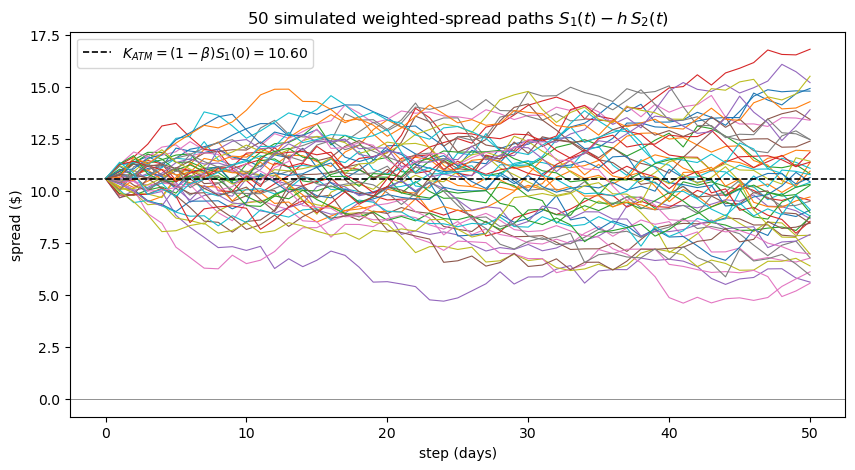

In [21]:
# Simulator validation at the calibrated state (A0, B0)
A, B = simulate_correlated_gbm(A0, B0, SIGMA1, SIGMA2, RHO, r_f, T,
                               n_steps, n_paths=400_000, rng=rng)

# checks
print(f"E[A(T)]: MC {A[:, -1].mean():.4f} vs exact {A0 * np.exp(r_f * T):.4f}")
print(f"E[B(T)]: MC {B[:, -1].mean():.4f} vs exact {B0 * np.exp(r_f * T):.4f}")
print(f"terminal log-corr: "
      f"{np.corrcoef(np.log(A[:, -1]), np.log(B[:, -1]))[0, 1]:.4f} "
      f"vs rho {RHO:.4f}")

payoff = np.maximum(A[:, -1] - B[:, -1], 0.0)
mc = np.exp(-r_f * T) * payoff.mean()
se = np.exp(-r_f * T) * payoff.std(ddof=1) / np.sqrt(len(payoff))
vm = margrabe_price(A0, B0, SIGMA1, SIGMA2, RHO, T)
print(f"K=0 exchange option: MC {mc:.4f} (SE {se:.4f}) vs Margrabe {vm:.4f} "
      f"-> |diff| = {abs(mc - vm) / se:.2f} SEs")

# sample weighted-spread paths with the ATM strike marked
plt.plot((A - B)[:50].T, lw=0.8)
plt.axhline(K_ATM, color="k", ls="--", lw=1.2,
            label=f"$K_{{ATM}} = (1-\\beta)S_1(0) = {K_ATM:.2f}$")
plt.axhline(0, color="grey", lw=0.6)
plt.title("50 simulated weighted-spread paths $S_1(t) - h\\,S_2(t)$")
plt.xlabel("step (days)")
plt.ylabel("spread ($)")
plt.legend()
plt.show()


Each leg should match its forward $S(0)e^{rT}$ to within Monte Carlo
noise, terminal log correlation should reproduce $\rho$, and the $K=0$ MC
price should agree with the Margrabe closed form within ~2 standard errors.
The spread paths start at $K_{\text{ATM}}$ and diffuse: under risk-neutral
GBM the spread is **not** mean-reverting. The OU dynamics of notebook 01
drive the *signal* under $\mathbb P$, while pricing under $\mathbb Q$ uses
no-arbitrage dynamics that ignore it. (Pricing consistent with cointegrated
dynamics is possible (Duan & Pliska 2004) and is noted as an extension in
the conclusions.)


# 3. Monte Carlo pricing of the spread option, with a control variate

## 3.1 Plain Monte Carlo

The spread option price is the discounted risk-neutral expectation
$$V(K) = e^{-rT}\,\mathbb E\big[\max(A(T) - B(T) - K,\ 0)\big],$$
estimated by the sample mean $\hat V = e^{-rT}\frac1N\sum_{j=1}^N P_j$ over
payoffs $P_j$ on i.i.d. simulated paths, with standard error
$\text{SE} = e^{-rT}\, s_P / \sqrt{N}$.

## 3.2 The Margrabe control variate

If $C$ is a random variable computed on the *same paths* with known mean
$\mathbb E[C]$, the estimator
$$\hat V_{cv} = \frac1N \sum_j \Big( P_j - b^*\,(C_j - \mathbb E[C]) \Big), \qquad b^* = \frac{\operatorname{Cov}(P, C)}{\operatorname{Var}(C)},$$
is unbiased with variance reduced by factor
$\dfrac{1}{1 - \operatorname{corr}(P, C)^2}$. (Estimating $b^*$ from the same
paths introduces $O(1/N)$ bias, which we ignore in practice.)

Here $C = \max(A(T) - B(T),\, 0)$ is the *undiscounted* $K{=}0$ payoff with
known mean $\mathbb E[C] = e^{rT} V_M$ from Sect. 2.2. The $K = 0$ and $K \neq 0$
payoffs are computed from the same terminal values, so they are strongly
correlated for strikes within a few spread-sigmas of $0$ — which includes
$K_{\text{ATM}}$, the strike the backtest trades. $K = 0$ stays in the grid
as an exactness check: there the control *equals* the payoff, so the
estimator returns the closed form with zero variance.


In [23]:
def _cv_adjust(P, C, EC):
    """Same-sample control-variate adjustment. Returns adjusted payoffs, b*, corr."""
    cov = np.cov(P, C, ddof=1)
    var_C = cov[1, 1]
    if var_C < 1e-14:                      
        return P, 0.0, 0.0
    b_star = cov[0, 1] / var_C
    corr = cov[0, 1] / np.sqrt(cov[0, 0] * var_C) if cov[0, 0] > 0 else 0.0
    return P - b_star * (C - EC), b_star, corr


def mc_spread_option_plain(A_T, B_T, K, r, T):
    """Plain MC price + SE."""
    P = np.maximum(A_T - B_T - K, 0.0)
    disc = np.exp(-r * T)
    return disc * P.mean(), disc * P.std(ddof=1) / np.sqrt(len(P))


def mc_spread_option_margrabe_cv(A_T, B_T, K, r, T, margrabe_V):
    """Margrabe CV: C = max(A_T - B_T, 0) undiscounted, E[C] = e^{rT} V_M."""
    P = np.maximum(A_T - B_T - K, 0.0)
    C = np.maximum(A_T - B_T, 0.0)
    P_adj, b_star, corr = _cv_adjust(P, C, np.exp(r * T) * margrabe_V)
    disc = np.exp(-r * T)
    return (disc * P_adj.mean(),
            disc * P_adj.std(ddof=1) / np.sqrt(len(P_adj)), b_star, corr)


def variance_reduction_study(K_grid, N_grid, params, rng):
    """Both estimators on shared paths per (K, N)."""
    p = params
    rows = []
    N_max = max(N_grid)

    A, B = simulate_correlated_gbm(p["A0"], p["B0"], p["sigma1"],
                                   p["sigma2"], p["rho"], p["r"], p["T"],
                                   p["n_steps"], N_max, rng)
    vm = margrabe_price(p["A0"], p["B0"], p["sigma1"], p["sigma2"],
                        p["rho"], p["T"])

    for N in N_grid:
        aT, bT = A[:N, -1], B[:N, -1]
        for K in K_grid:
            t0 = time.perf_counter()
            pr, se = mc_spread_option_plain(aT, bT, K, p["r"], p["T"])
            rows.append((K, N, "plain", pr, se, 1.0, np.nan,
                         time.perf_counter() - t0))
            se_plain = se

            t0 = time.perf_counter()
            pr, se, bs, c = mc_spread_option_margrabe_cv(aT, bT, K,
                                                         p["r"], p["T"], vm)
            rows.append((K, N, "margrabe_cv", pr, se, (se_plain/se)**2
                         if se > 0 else np.inf, c,
                         time.perf_counter() - t0))

    return pd.DataFrame(rows, columns=["K", "N", "estimator", "price",
                                       "se", "vr_ratio", "corr_PC",
                                       "seconds"])

strike grid: [0.0, 7.47, 10.6, 13.72, 16.84]  (ATM = 10.6, 1-sigma = 3.12)


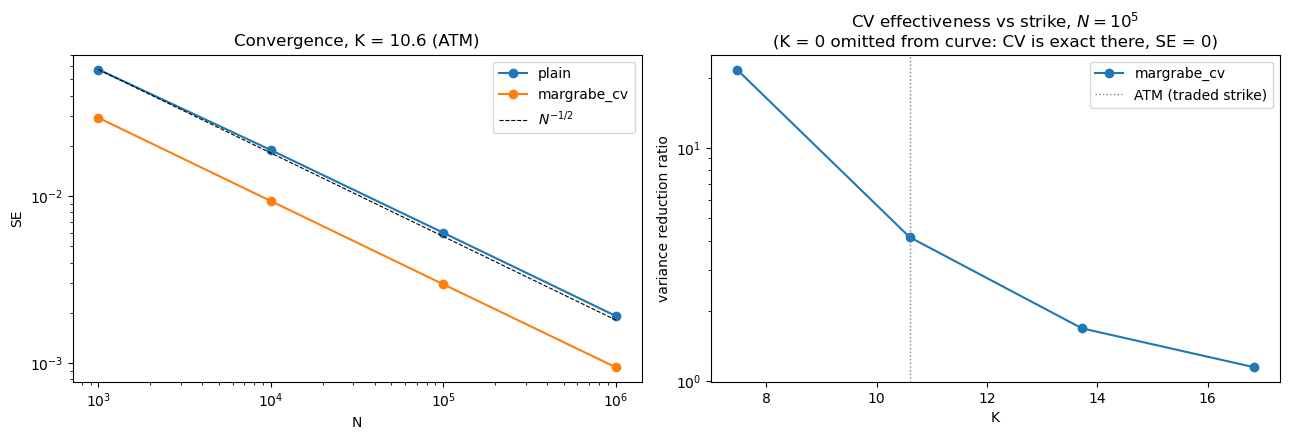

,K,N,estimator,price,se,vr_ratio,corr_PC,seconds
20,0.00,100000,plain,10.5930,0.0098,1.0000,NaN,0.0166
21,0.00,100000,margrabe_cv,10.5961,0.0000,inf,1.0000,0.0133
22,7.47,100000,plain,3.4062,0.0087,1.0000,NaN,0.0063
23,7.47,100000,margrabe_cv,3.4088,0.0019,21.6584,0.9766,0.0141
24,10.60,100000,plain,1.2748,0.0060,1.0000,NaN,0.0067
25,10.60,100000,margrabe_cv,1.2764,0.0030,4.1368,0.8708,0.0128
26,13.72,100000,plain,0.2948,0.0029,1.0000,NaN,0.0046
27,13.72,100000,margrabe_cv,0.2954,0.0023,1.6829,0.6370,0.0142
28,16.84,100000,plain,0.0419,0.0010,1.0000,NaN,0.0052
29,16.84,100000,margrabe_cv,0.0420,0.0010,1.1461,0.3570,0.0150


In [24]:
K_GRID = [0.0,
          float(round(K_ATM - SPREAD_SIGMA, 2)),
          float(round(K_ATM, 2)),
          float(round(K_ATM + SPREAD_SIGMA, 2)),
          float(round(K_ATM + 2 * SPREAD_SIGMA, 2))]
K_CONV = K_GRID[2]     # convergence plot at the traded (ATM) strike
print(f"strike grid: {K_GRID}  (ATM = {K_CONV}, 1-sigma = {SPREAD_SIGMA:.2f})")

params = dict(A0=A0, B0=B0, sigma1=SIGMA1, sigma2=SIGMA2,
              rho=RHO, r=r_f, T=T, n_steps=n_steps)

results = variance_reduction_study(K_grid=K_GRID,
                                   N_grid=[10**3, 10**4, 10**5, 10**6],
                                   params=params, rng=rng)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# convergence plot: SE vs N at the ATM strike
for est in ["plain", "margrabe_cv"]:
    d = results.query("K == @K_CONV and estimator == @est")
    ax1.loglog(d.N, d.se, "o-", label=est)
se_ref = results.query("K == @K_CONV and estimator == 'plain' and N == 1000").se.iloc[0]
ax1.loglog([1e3, 1e6], [se_ref, se_ref / np.sqrt(1000)],
           "k--", lw=0.8, label=r"$N^{-1/2}$")
ax1.set_xlabel("N")
ax1.set_ylabel("SE")
ax1.set_title(f"Convergence, K = {K_CONV} (ATM)")
ax1.legend()

# variance-reduction ratio vs strike, N = 10^5
d = results.query("N == 100000 and estimator == 'margrabe_cv'")
finite = d[np.isfinite(d.vr_ratio)]
ax2.semilogy(finite.K, finite.vr_ratio, "o-", label="margrabe_cv")
ax2.axvline(K_CONV, color="grey", ls=":", lw=1, label="ATM (traded strike)")
ax2.set_xlabel("K")
ax2.set_ylabel("variance reduction ratio")
ax2.set_title(r"CV effectiveness vs strike, $N = 10^5$"
              "\n(K = 0 omitted from curve: CV is exact there, SE = 0)")
ax2.legend()
plt.tight_layout()
plt.show()

results.query("N == 100000").round(4)


The convergence study (left) confirms both estimators exhibit the canonical N^(−1/2) Monte Carlo rate; 
the Margrabe control does not change the rate but shifts the error curve down by a constant factor of roughly two in standard error, a ~4× variance reduction, 
meaning the CV estimator with N paths matches the accuracy plain MC needs ~4N paths to reach. 

This agrees with the measured corr(P, C) ≈ 0.85, which implies a reduction of 1/(1 − ρ²) ≈ 3.6 at the optimal coefficient. 
The strike sweep (right) shows the benefit is strongest where the payoff is most linear in the terminal spread: exact at K = 0 
(the control equals the payoff, zero variance, omitted from the log-scale curve), ~20× deep in the money, 
~4× at the traded ATM strike where convexity caps the correlation, and fading to ~1.1× deep out of the money as the payoff decorrelates from the near-linear control. 
The reduction is thus largest precisely in the region this project prices.